# Evidencia del modelo de peso y del segmentador

Estimación de peso bovino por visión. Este cuaderno reproduce, desde los archivos versionados en este repositorio, el
modelo de peso que lleva la aplicación (campaña de calibración del 12 de septiembre de 2026: 40 vacas Jersey adultas,
una fotografía lateral por animal, referencia por cinta bovinométrica), lo compara con el paquete desplegado, mide la
repetibilidad entre fotografías del mismo animal y resume el predictor alternativo explorado. Después reúne la evidencia
del segmentador y del dispositivo: IoU contra máscaras manuales, paridad entre computadora y Galaxy A25, tiempos medidos
en el teléfono y golden de la aplicación. Cierra con el modelo del piloto de junio de 2026 y su transferencia a la campaña.

Importa las funciones de `pipeline/src/eval_weight_campana.py` y `pipeline/src/eval_weight_fotos_hoy.py`, de modo que el
cálculo es el de los scripts y no una copia. Se ejecutó con el entorno del pipeline (`pipeline/requirements-lock.txt` más
`ipykernel`). Todos los archivos que lee están en este repositorio.

In [ ]:
%matplotlib inline
import json, sys, math
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "pipeline").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "pipeline" / "src"))
from eval_weight_campana import leer_csv, leer_pesos, seleccionar_fotos, evaluate, fit, predict
from eval_weight_fotos_hoy import FEATURES, mape, rmse, loo_predict, loo_predict_loglog, boot_ci_mape

CAMPANA = ROOT / "pipeline/data/field/campana_20260912"
INFORME = ROOT / "informes/campana_20260912"
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20); pd.set_option("display.max_rows", 60)
plt.rcParams["figure.dpi"] = 100

## 1. Datos de la campaña: 40 animales, una fotografía por animal

`bitacora_campana_20260912.csv` fija la identidad (fila, nombre, arete); `pesos_20260920.csv` trae la lectura de cinta
bovinométrica del 20 de septiembre de 2026, una por animal; `medidas_app_3m_20260912.csv` contiene las 200 fotografías
preseleccionadas (cinco por animal, las más cercanas a 3.0 m) medidas por la ruta de la aplicación reproducida en
computadora (jpeg-js, LiteRT FP32, `segment.ts`, js-aruco2). Entra una fotografía por animal: la primaria o, si la ruta la
rechazó, la siguiente aceptada del orden de preselección. La selección se fijó antes de conocer los pesos.

In [ ]:
bitacora = {r["fila"].strip(): {"nombre": r["nombre"].strip(), "arete": r["arete"].strip()} for r in leer_csv(CAMPANA / "bitacora_campana_20260912.csv")}
medidas = leer_csv(CAMPANA / "medidas_app_3m_20260912.csv")
animales = sorted({m["fila"] for m in medidas}, key=int)
refs, sin_peso = leer_pesos(CAMPANA / "pesos_20260920.csv", {f: bitacora[f] for f in animales})
seleccion, sustituciones = seleccionar_fotos(medidas, animales)
ids = [f for f in animales if f in refs and f in seleccion]
area = np.array([float(seleccion[f]["area_cm2"]) for f in ids]); y = np.array([refs[f]["peso_ref_kg"] for f in ids])
datos = pd.DataFrame({"fila": [int(f) for f in ids], "nombre": [bitacora[f]["nombre"] for f in ids],
                      "arete": [bitacora[f]["arete"] or "—" for f in ids], "fotografía": [seleccion[f]["foto"] for f in ids],
                      "distancia m": [float(seleccion[f]["distancia_previa_m"]) for f in ids],
                      "área cm²": area.round(1), "peso de referencia kg": y.round(1)}).set_index("fila")
print(f"n = {len(ids)} animales con fotografía aceptada y referencia (sin peso: {sin_peso or 'ninguno'}) · "
      f"peso {y.min():.0f}–{y.max():.0f} kg (media {y.mean():.0f}, sd {y.std(ddof=1):.0f}) · área {area.min():.0f}–{area.max():.0f} cm²")
for s in sustituciones:
    print(f"Sustitución: fila {s['fila']} ({bitacora[s['fila']]['nombre']}), primaria {s['foto_primaria']} rechazada por "
          f"{s['motivo_primaria']}; entra {s['foto']} (orden {s['rango_3m']})")
datos

n = 40 animales con fotografía aceptada y referencia (sin peso: ninguno) · peso 282–474 kg (media 385, sd 46) · área 9808–16899 cm²
Sustitución: fila 7 (Keila), primaria IMG_20260912_070836.jpg rechazada por sin_vaca; entra IMG_20260912_070835.jpg (orden 3)


,nombre,arete,fotografía,distancia m,área cm²,peso de referencia kg
fila,,,,,,
1,Estrellita,197260,IMG_20260912_065058.jpg,3.106,16159.6,410.5
2,Rosalinda,236681,IMG_20260912_065501.jpg,2.782,12018.6,367.4
3,Irina,207898,IMG_20260912_065723.jpg,3.030,15894.0,397.3
4,Realta,207903,IMG_20260912_065953.jpg,3.090,15864.6,410.5
5,Damita,73148,IMG_20260912_070206.jpg,3.120,16749.0,449.1
6,Señorita,207916,IMG_20260912_070540.jpg,3.156,16229.8,379.7
7,Keila,73161,IMG_20260912_070835.jpg,2.990,14931.8,432.7
8,Gaby,223678,IMG_20260912_071104.jpg,3.038,14112.1,337.9
9,Cerezita,—,IMG_20260912_071338.jpg,3.170,15916.4,438.2


## 2. Modelo alométrico con validación leave-one-out por animal

`evaluate` reajusta $a$, $b$ y el intervalo de predicción sin el animal evaluado, una vez por animal, y calcula el MAPE con
su IC95 bootstrap por animal (B = 2000, semilla fija), MAE, RMSE, R² y la cobertura del intervalo de predicción al 95 %.
El análisis secundario preespecificado usa la mediana del área de las fotografías aceptadas de cada animal. Las cifras se
contrastan con `informes/campana_20260912/peso/evaluacion.json`, que escribió `eval_weight_campana.py`.

In [ ]:
primario = evaluate(area, y, ids)
aceptadas = {f: [m for m in medidas if m["fila"] == f and m["estado"] == "ok" and m["revision_visual"] == "aceptar"] for f in ids}
secundario = evaluate([float(np.median([float(m["area_cm2"]) for m in aceptadas[f]])) for f in ids], y, ids)
informe = json.loads((INFORME / "peso/evaluacion.json").read_text())
def fila_metricas(m):
    return {"n": m["n_animales"], "MAPE %": round(m["mape_pct"], 2), "IC95 del MAPE": f"[{m['mape_ic95_pct'][0]:.2f}, {m['mape_ic95_pct'][1]:.2f}]",
            "MAE kg": round(m["mae_kg"], 1), "RMSE kg": round(m["rmse_kg"], 1), "R²": round(m["r2"], 2),
            "cobertura IP95 %": round(m["ip95_cobertura_loo"] * 100, 1)}
tabla = pd.DataFrame({"una fotografía por animal (primario)": fila_metricas(primario["metricas"]),
                      "mediana de las fotografías aceptadas (secundario)": fila_metricas(secundario["metricas"]),
                      "informe peso/evaluacion.json (primario)": fila_metricas(informe["primary"]["metricas"])}).T
dif = abs(primario["metricas"]["mape_pct"] - informe["primary"]["metricas"]["mape_pct"])
print(f"H1a (MAPE < 10 %): valor puntual {'sí' if primario['metricas']['h1a_mape_menor_10'] else 'no'}; "
      f"límite superior del IC95 {'sí' if primario['metricas']['h1a_ic95_superior_menor_10'] else 'no'}. "
      f"Diferencia con el informe: {dif:.1e} puntos de MAPE.")
tabla

H1a (MAPE < 10 %): valor puntual sí; límite superior del IC95 sí. Diferencia con el informe: 0.0e+00 puntos de MAPE.


,n,MAPE %,IC95 del MAPE,MAE kg,RMSE kg,R²,cobertura IP95 %
una fotografía por animal (primario),40,7.72,"[5.98, 9.57]",29.0,36.1,0.36,97.5
mediana de las fotografías aceptadas (secundario),40,7.8,"[6.02, 9.63]",29.4,36.4,0.35,97.5
informe peso/evaluacion.json (primario),40,7.72,"[5.98, 9.57]",29.0,36.1,0.36,97.5


## 3. Coeficientes del paquete que lleva la aplicación

Ajuste completo sobre los 40 animales de $\ln W = \ln a + b \cdot \ln A$, frente a `app/assets/model_bundle/weight_model.json`,
que es lo que la aplicación lee en tiempo de ejecución: coeficientes, parámetros del intervalo de predicción log-log al
95 % y rango de calibración. Los coeficientes no están escritos en el código de la aplicación.

In [ ]:
ajuste = fit(area, y); bundle = json.loads((ROOT / "app/assets/model_bundle/weight_model.json").read_text())
iv, ib = ajuste["interval"], bundle["interval"]
print("versión del paquete:", bundle["version"], "·", bundle["fuente"])
comparacion = pd.DataFrame({"ajuste sobre los 40": [ajuste["a"], ajuste["b"], iv["n"], iv["sigma_log"], iv["t_critical"], iv["area_min"], iv["area_max"]],
                            "weight_model.json": [bundle["a"], bundle["b"], ib["n"], ib["sigma_log"], ib["t_critical"], ib["area_min"], ib["area_max"]]},
                           index=["a", "b", "n", "σ_log", "t crítico", "área mínima cm²", "área máxima cm²"])
comparacion["iguales"] = np.isclose(comparacion.iloc[:, 0].astype(float), comparacion.iloc[:, 1].astype(float), rtol=0, atol=1e-9)
comparacion

versión del paquete: campana-994d9c2cd1a6 · Campaña 2026-09-12; una fotografía por animal; LOO por animal, n = 40; referencias con fecha declarada


,ajuste sobre los 40,weight_model.json,iguales
a,2.341031,2.341031,True
b,0.534733,0.534733,True
n,40.000000,40.000000,True
σ_log,0.092415,0.092415,True
t crítico,2.024394,2.024394,True
área mínima cm²,9808.025364,9808.025364,True
área máxima cm²,16898.985933,16898.985933,True


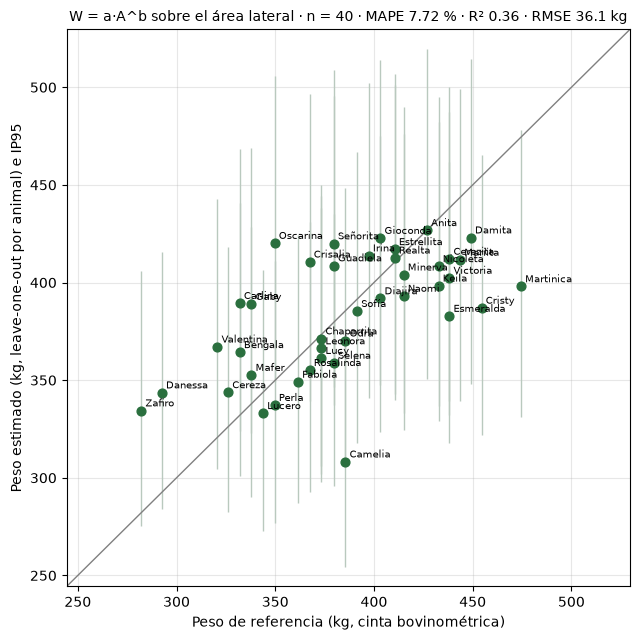

In [ ]:
pred = np.array([p["pred_loo_kg"] for p in primario["predicciones"]])
lo = np.array([p["ip95_lo_kg"] for p in primario["predicciones"]]); hi = np.array([p["ip95_hi_kg"] for p in primario["predicciones"]])
m = primario["metricas"]
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.errorbar(y, pred, yerr=[pred - lo, hi - pred], fmt="none", ecolor="#b9c9be", elinewidth=1, zorder=2)
ax.scatter(y, pred, s=40, color="#2a6f3e", zorder=3)
for w, p, f in zip(y, pred, ids):
    ax.annotate(bitacora[f]["nombre"], (w, p), fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [min(y.min(), lo.min()) - 10, max(y.max(), hi.max()) + 10]
ax.plot(lim, lim, color="gray", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Peso de referencia (kg, cinta bovinométrica)"); ax.set_ylabel("Peso estimado (kg, leave-one-out por animal) e IP95")
ax.set_title(f"W = a·A^b sobre el área lateral · n = {m['n_animales']} · MAPE {m['mape_pct']:.2f} % · R² {m['r2']:.2f} · RMSE {m['rmse_kg']:.1f} kg", fontsize=10)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Repetibilidad entre fotografías del mismo animal

Las fotografías aceptadas de las cinco preseleccionadas a 3 m de cada animal se predicen con el modelo del pliegue que dejó
fuera a ese animal. El ICC(1) del logaritmo del área es el del logaritmo del peso para cualquier modelo alométrico; el
coeficiente de variación y el rango del peso predicho por animal son la dispersión que ve el usuario al repetir la
fotografía. Se muestran los ocho animales de mayor rango.

In [ ]:
def icc1(grupos):
    N = sum(map(len, grupos)); k = len(grupos); media = np.mean([v for g in grupos for v in g])
    msb = sum(len(g) * (np.mean(g) - media) ** 2 for g in grupos) / (k - 1)
    msw = sum(sum((v - np.mean(g)) ** 2 for v in g) for g in grupos) / (N - k)
    n0 = (N - sum(len(g) ** 2 for g in grupos) / N) / (k - 1)
    return (msb - msw) / (msb + (n0 - 1) * msw)
pliegue = {p["animal_test"]: p["modelo"] for p in primario["pliegues"]}
pesos_rep = {f: [float(predict(pliegue[f], float(m["area_cm2"]))[0]) for m in aceptadas[f]] for f in ids}
rep = pd.DataFrame({"nombre": [bitacora[f]["nombre"] for f in ids], "fotografías": [len(v) for v in pesos_rep.values()],
                    "CV del peso %": [np.std(v, ddof=1) / np.mean(v) * 100 for v in pesos_rep.values()],
                    "rango del peso kg": [max(v) - min(v) for v in pesos_rep.values()]}, index=pd.Index([int(f) for f in ids], name="fila"))
icc = icc1([[math.log(float(m["area_cm2"])) for m in aceptadas[f]] for f in ids])
print(f"{rep['fotografías'].sum()} fotografías de {len(ids)} animales · ICC(1) del logaritmo del área {icc:.3f} "
      f"(informe: {informe['repeatability']['icc1_log_area']:.3f}) · CV del peso: mediana {rep['CV del peso %'].median():.2f} %, "
      f"máximo {rep['CV del peso %'].max():.2f} % · rango del peso por animal: mediana {rep['rango del peso kg'].median():.1f} kg, "
      f"máximo {rep['rango del peso kg'].max():.1f} kg")
rep.round(2).sort_values("rango del peso kg", ascending=False).head(8)

196 fotografías de 40 animales · ICC(1) del logaritmo del área 0.978 (informe: 0.978) · CV del peso: mediana 0.85 %, máximo 3.52 % · rango del peso por animal: mediana 7.0 kg, máximo 36.8 kg


,nombre,fotografías,CV del peso %,rango del peso kg
fila,,,,
1,Estrellita,5,3.52,36.77
39,Gioconda,5,2.29,23.78
4,Realta,5,2.35,23.56
8,Gaby,4,3.07,22.44
30,Victoria,5,1.94,21.15
11,Crisalia,5,2.04,17.58
12,Oscarina,5,1.60,17.30
14,Carlina,5,1.65,15.29


## 5. Predictor alternativo explorado: profundidad corporal proyectada

`informes/campana_20260912/peso_profundidad/` evalúa, sobre los mismos 40 animales y las mismas fotografías, un modelo de
exponente fijo sobre la profundidad corporal proyectada media de la banda central de la silueta
(`measure_depth_campana.py`, `eval_weight_depth_campana.py`). Aquí se leen sus métricas y se calcula su repetibilidad
con el criterio del apartado 4, con el ajuste completo de cada modelo. Es más exacto en promedio y menos repetible
entre fotografías; la diferencia de MAPE queda bajo la resolución del estudio y no se validó frente a báscula. La
aplicación estima con el área.

In [ ]:
prof = json.loads((INFORME / "peso_profundidad/evaluacion.json").read_text())
bprof = json.loads((INFORME / "peso_profundidad/weight_model.json").read_text())
dmed = {r["foto"]: r for r in leer_csv(CAMPANA / "profundidad_app_3m_20260912.csv")}
fotos = {f: [m for m in aceptadas[f] if dmed.get(m["foto"], {}).get("estado_profundidad") == "ok"] for f in ids}
def repetibilidad(valor, a, b):
    w = {f: [a * valor(m) ** b for m in fotos[f]] for f in ids}
    return {"ICC(1) log": round(icc1([[math.log(valor(m)) for m in fotos[f]] for f in ids]), 3),
            "CV del peso % (mediana)": round(float(np.median([np.std(v, ddof=1) / np.mean(v) * 100 for v in w.values()])), 2),
            "rango del peso kg (mediana)": round(float(np.median([max(v) - min(v) for v in w.values()])), 1),
            "rango del peso kg (máximo)": round(float(max(max(v) - min(v) for v in w.values())), 1)}
def resumen(mtr, rep):
    return {"MAPE %": round(mtr["mape_pct"], 2), "IC95 del MAPE": f"[{mtr['mape_ic95_pct'][0]:.2f}, {mtr['mape_ic95_pct'][1]:.2f}]",
            "R²": round(mtr["r2"], 2), "RMSE kg": round(mtr["rmse_kg"], 1), **rep}
comparativa = pd.DataFrame({
    "área W = a·A^b (aplicación)": resumen(prof["area"]["metricas"], repetibilidad(lambda m: float(m["area_cm2"]), ajuste["a"], ajuste["b"])),
    "profundidad W = a·D (explorado)": resumen(prof["primary"]["metricas"], repetibilidad(lambda m: float(dmed[m["foto"]]["d_media_cm"]), bprof["a"], bprof["b"])),
}).T
c, inf = prof["comparacion_area"], prof["influencia"]
print(f"{sum(map(len, fotos.values()))} fotografías de {len(ids)} animales · diferencia pareada de MAPE {c['delta_mape_pct']:+.2f} puntos "
      f"(IC95 bootstrap por animal [{c['delta_ic95_pct'][0]:.2f}, {c['delta_ic95_pct'][1]:.2f}]), mejora en {c['animales_que_mejoran']} de {c['n_animales']} · "
      f"sin los tres animales más favorables conserva el {inf['conserva_fraccion']*100:.0f} % de la ganancia "
      f"({inf['delta_mape_pct']:+.2f} [{inf['delta_ic95_pct'][0]:.2f}, {inf['delta_ic95_pct'][1]:+.2f}])")
comparativa

196 fotografías de 40 animales · diferencia pareada de MAPE -1.18 puntos (IC95 bootstrap por animal [-2.18, -0.25]), mejora en 25 de 40 · sin los tres animales más favorables conserva el 64 % de la ganancia (-0.76 [-1.71, +0.15])


,MAPE %,IC95 del MAPE,R²,RMSE kg,ICC(1) log,CV del peso % (mediana),rango del peso kg (mediana),rango del peso kg (máximo)
área W = a·A^b (aplicación),7.72,"[5.98, 9.57]",0.36,36.1,0.978,0.83,7.0,36.5
profundidad W = a·D (explorado),6.54,"[5.01, 8.18]",0.5,31.9,0.968,1.22,11.2,42.5


## 6. Fotografías de la campaña y control del segmentador

`informes/campana_20260912/mosaico_seleccion_3m.jpg`: la fotografía primaria de cada uno de los 40 animales, con el
marcador ArUco de 15 cm sostenido junto al costado; el rótulo da la fila, el nombre y la distancia estimada desde el
marcador. Debajo, una imagen de control del conjunto de validación manual (`informes/iou_val_manual_apk_20260909/img/`):
máscara de referencia pintada a mano (amarillo la vaca objetivo, azul las demás), salida del `.pt` en computadora y salida
de la ruta del APK (LiteRT), con el IoU y el error de área de cada una, en una escena con varias vacas.

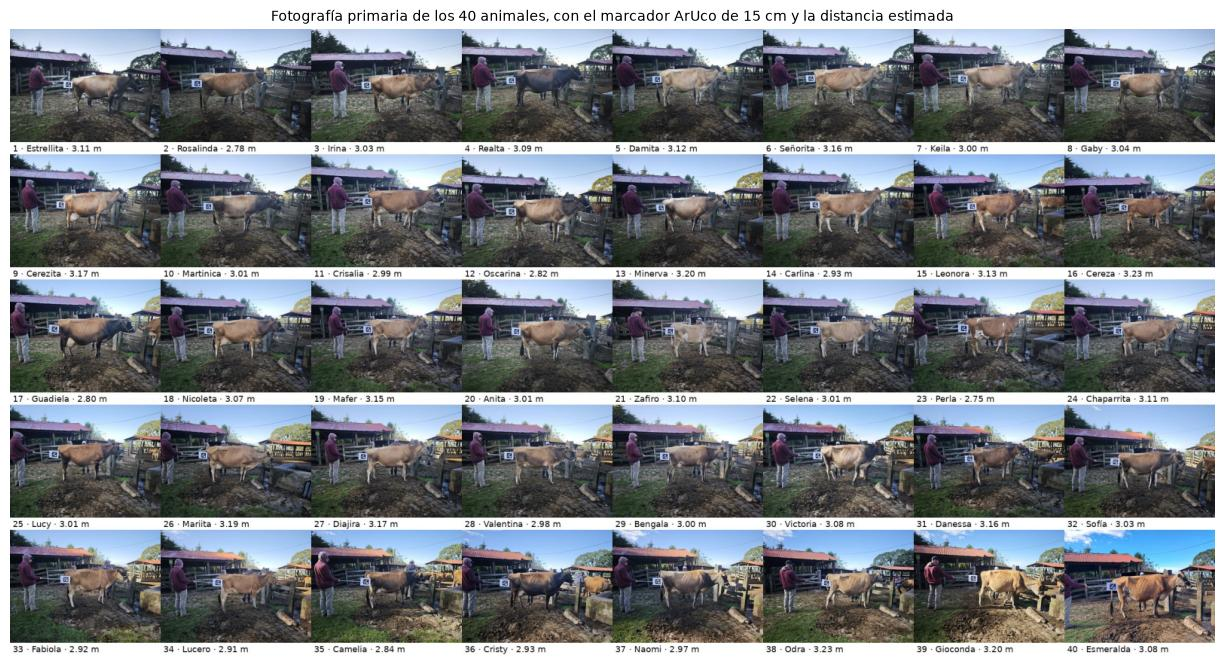

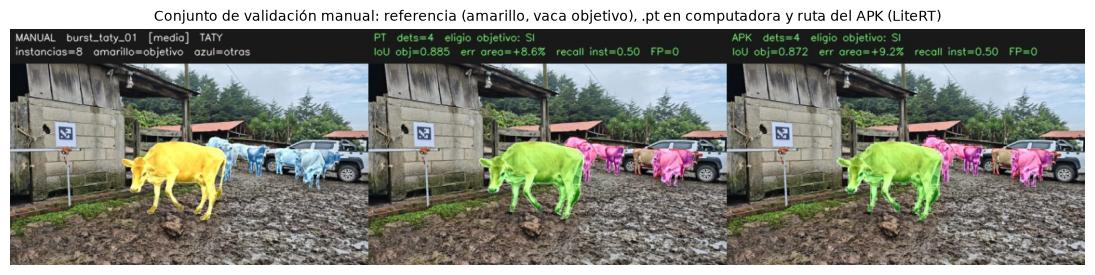

In [ ]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('jpeg')   # fotografías: JPEG pesa diez veces menos que PNG
def mostrar(ruta, ancho, titulo):
    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB); escala = ancho / img.shape[1]
    img = cv2.resize(img, (ancho, int(img.shape[0] * escala)), interpolation=cv2.INTER_AREA)
    fig, ax = plt.subplots(figsize=(13, 13 * img.shape[0] / img.shape[1]))
    ax.imshow(img); ax.axis("off"); ax.set_title(titulo, fontsize=10); plt.tight_layout(); plt.show()
mostrar(INFORME / "mosaico_seleccion_3m.jpg", 1600, "Fotografía primaria de los 40 animales, con el marcador ArUco de 15 cm y la distancia estimada")
mostrar(ROOT / "informes/iou_val_manual_apk_20260909/img/burst_taty_01.jpg", 1600,
        "Conjunto de validación manual: referencia (amarillo, vaca objetivo), .pt en computadora y ruta del APK (LiteRT)")
set_matplotlib_formats('png')

## 7. Segmentador desplegado contra las 40 máscaras manuales

`informes/iou_val_manual_apk_20260909/resumen.json`: la ruta del APK (LiteRT FP32, letterbox 640×640, umbral 0.5,
vaca de mayor área) y el `.pt` de computadora, evaluados sobre `pipeline/data/val_clean/` (40 imágenes, 24 animales, tres
estratos: laterales controladas, ráfagas con varias vacas, casos difíciles). La referencia son máscaras pintadas a mano.

In [ ]:
iou = json.loads((ROOT / "informes/iou_val_manual_apk_20260909/resumen.json").read_text())
filas = []
for estrato, modelos in iou["por_estrato"].items():
    for modelo, mm in modelos.items():
        filas.append({"estrato": estrato, "modelo": {"apk": "ruta del APK (LiteRT)", "pt": ".pt en computadora"}[modelo], "n": mm["n"],
                      "eligió la vaca correcta %": mm["eligio_objetivo_pct"], "sin detección": mm["sin_deteccion"],
                      "IoU vaca objetivo": mm["iou_objetivo"], "error de área medio %": mm["err_area_medio_pct"]})
boot = iou["bootstrap_por_animal"]["apk"]["iou_objetivo"]
print(f"Diferencia APK − .pt en IoU (bootstrap por animal, n = {boot['n_grupos']}): {boot['dif_media']:+.3f}, IC95 {boot['ic95']}")
pd.DataFrame(filas).set_index(["estrato", "modelo"])

Diferencia APK − .pt en IoU (bootstrap por animal, n = 24): +0.024, IC95 [-0.0061, 0.0723]


n  eligió la vaca correcta %  sin detección  IoU vaca objetivo  error de área medio %
estrato modelo                                                                                                       
facil   .pt en computadora     15                      100.0              0              0.929                    4.2
        ruta del APK (LiteRT)  15                      100.0              0              0.924                    3.8
media   .pt en computadora     15                       86.7              0              0.780                   10.7
        ruta del APK (LiteRT)  15                       86.7              0              0.770                   12.3
dificil .pt en computadora     10                       80.0              2              0.748                  -16.3
        ruta del APK (LiteRT)  10                      100.0              0              0.932                    4.9
total   .pt en computadora     40                       90.0              2              0.828                    1.5
        ruta del APK (LiteRT)  40                       95.0              0              0.868                    7.2

## 8. Paridad entre computadora y teléfono, y tiempos en el Galaxy A25

`informes/paridad_segmentador_20260909/resumen.json`: la emulación de la ruta del APK en computadora frente a lo que
registró el A25 sobre las mismas 10 fotografías, y LiteRT frente al `.pt`. `informes/benchmark_a25_20260826_fullres.json`:
tiempos medidos en el dispositivo en agosto de 2026 con fotografías de 1280×960 (una corrida de calentamiento y cinco
medidas por fotografía).

In [ ]:
par = json.loads((ROOT / "informes/paridad_segmentador_20260909/resumen.json").read_text())["A_benchmark_a25"]
bm = json.loads((ROOT / "informes/benchmark_a25_20260826_fullres.json").read_text())
aruco_ms = np.mean([a["aruco_ms"] for a in bm["aruco"]])
pd.DataFrame({"valor": [
    f"{par['dets_iguales_pc_vs_a25']} de {par['n_fotos']}",
    f"{par['dif_area_pc_litert_vs_a25_pct']['media']:+.3f} % media · |máx| {par['dif_area_pc_litert_vs_a25_pct']['abs_max']:.3f} %",
    f"{par['dif_area_litert_vs_pt_pct']['media']:+.3f} % media · |máx| {par['dif_area_litert_vs_pt_pct']['abs_max']:.3f} % (criterio ≤ 1 %: {'cumple' if par['criterio_area_le_1pct'] else 'no cumple'})",
    f"{bm['device']['model_name']} · Android {bm['device']['os_version']} · {bm['device']['total_memory_mb']} MB",
    f"{bm['summary']['fp32']['p50_ms']:.0f} / {bm['summary']['fp32']['p95_ms']:.0f} ms ({bm['summary']['fp32']['count']} medidas)",
    f"{bm['summary']['aruco_decoded']} de {bm['summary']['aruco_total']} · {aruco_ms:.0f} ms por fotografía",
    f"{bm['cold_start_ms']/1000:.2f} s",
]}, index=["Mismas detecciones computadora vs A25", "Área computadora-LiteRT vs A25", "Área LiteRT vs .pt", "Dispositivo",
           "Segmentación FP32 p50 / p95 (1280×960)", "Marcador decodificado (resolución fuente)", "Arranque en frío"])

,valor
Mismas detecciones computadora vs A25,10 de 10
Área computadora-LiteRT vs A25,-0.014 % media · |máx| 0.205 %
Área LiteRT vs .pt,-0.252 % media · |máx| 0.619 % (criterio ≤ 1 %...
Dispositivo,SM-A256E · Android 16 · 7398 MB
Segmentación FP32 p50 / p95 (1280×960),456 / 470 ms (50 medidas)
Marcador decodificado (resolución fuente),10 de 10 · 1408 ms por fotografía
Arranque en frío,3.97 s


### Latencia con originales de 12 MP en la compilación de entrega

El banco de agosto no representa la latencia de los originales de 12 MP que produce el teléfono.
`informes/benchmark_release_a25_20260919/bench_bateria2_20260919_0855.csv` registra, en una compilación Android de
lanzamiento sobre el A25 (19 de septiembre de 2026), 66 corridas sobre seis fotografías originales de la campaña: una de
acondicionamiento y cinco medidas por fotografía en cada modo (A, `estimarPeso` sin alterar; B, las mismas funciones con
marcas de tiempo entre etapas). El requisito RNF-02 de 3 s por fotografía no se cumple a esa resolución: la inferencia es
una fracción pequeña del total y el resto es decodificación JPEG y ArUco en JavaScript.

In [ ]:
lat = pd.read_csv(ROOT / "informes/benchmark_release_a25_20260919/bench_bateria2_20260919_0855.csv")
lat["ok"] = lat["ok"].astype(str).str.lower().eq("true")
med = lat[lat["fase"] != "acondicionamiento"].copy()
for c in ["ms_jpeg", "ms_inferencia", "ms_aruco"]:
    med[c] = pd.to_numeric(med[c], errors="coerce")
B = med[med["modo"] == "B"].groupby("archivo")
latencia = pd.DataFrame({"resultado": med.groupby("archivo")["ok"].first().map({True: "aceptada", False: "rechazo sin animal"}),
                         "total modo A (s)": med[med["modo"] == "A"].groupby("archivo")["total_ms"].median() / 1000,
                         "total modo B (s)": B["total_ms"].median() / 1000, "JPEG (s)": B["ms_jpeg"].median() / 1000,
                         "inferencia (s)": B["ms_inferencia"].median() / 1000, "ArUco (s)": B["ms_aruco"].median() / 1000}).round(2)
latencia = latencia.sort_values("total modo B (s)", ascending=False)
acept = latencia[latencia["resultado"] == "aceptada"]
print(f"{len(med)} corridas medidas sobre {lat['archivo'].nunique()} fotografías de 12 MP · fotografías aceptadas: mediana "
      f"{acept[['total modo A (s)', 'total modo B (s)']].min().min():.1f}–{acept[['total modo A (s)', 'total modo B (s)']].max().max():.1f} s "
      f"por fotografía, inferencia {acept['inferencia (s)'].median():.2f} s · rechazos sin animal: "
      f"{latencia.loc[latencia['resultado'] != 'aceptada', 'total modo B (s)'].min():.1f}–{latencia.loc[latencia['resultado'] != 'aceptada', 'total modo A (s)'].max():.1f} s (ArUco no se ejecuta)")
latencia.fillna("no se ejecuta")

60 corridas medidas sobre 6 fotografías de 12 MP · fotografías aceptadas: mediana 25.5–29.1 s por fotografía, inferencia 0.55 s · rechazos sin animal: 13.2–16.0 s (ArUco no se ejecuta)


,resultado,total modo A (s),total modo B (s),JPEG (s),inferencia (s),ArUco (s)
archivo,,,,,,
IMG_20260912_071121.jpg,aceptada,29.09,28.91,15.19,0.55,12.57
IMG_20260912_073927_2.jpg,aceptada,26.96,26.95,14.85,0.53,10.74
IMG_20260912_065052.jpg,aceptada,25.54,25.57,13.73,0.56,10.59
IMG_20260912_080328.jpg,rechazo sin animal,16.00,15.92,15.10,0.53,no se ejecuta
IMG_20260912_070836.jpg,rechazo sin animal,15.89,15.83,14.96,0.55,no se ejecuta
20260912_080628.jpg,rechazo sin animal,13.18,13.19,12.32,0.58,no se ejecuta


## 9. Golden de la aplicación

`app/assets/model_bundle/golden_cases.json`: diez áreas en el rango de calibración con el peso y los límites del intervalo
de predicción que la aplicación debe devolver; `npm run test:golden` los verifica con tolerancia 1e-8 kg. Aquí se
recalculan con `predict` y los coeficientes del paquete.

In [ ]:
golden = json.loads((ROOT / "app/assets/model_bundle/golden_cases.json").read_text())
g = pd.DataFrame(golden["casos"])
p, l, h = predict(bundle, g["area_cm2"].to_numpy(float))
g["peso_calculado_kg"], g["lo_calculado_kg"], g["hi_calculado_kg"] = p, l, h
dif = np.max(np.abs(np.column_stack([p - g["peso_esperado_kg"], l - g["limite_inferior_kg"], h - g["limite_superior_kg"]])))
print(f"{golden['modelo']} · {len(g)} casos · diferencia máxima {dif:.1e} kg (tolerancia {golden['tolerancia_kg']} kg)")
g[["foto", "area_cm2", "peso_esperado_kg", "peso_calculado_kg", "limite_inferior_kg", "limite_superior_kg"]].round(4)

campana-994d9c2cd1a6 · 10 casos · diferencia máxima 0.0e+00 kg (tolerancia 1e-08 kg)


,foto,area_cm2,peso_esperado_kg,peso_calculado_kg,limite_inferior_kg,limite_superior_kg
0,golden-0,9808.0254,319.0357,319.0357,260.9631,390.0314
1,golden-1,10419.2104,329.5170,329.5170,270.5270,401.3700
2,golden-2,11068.4814,340.3426,340.3426,280.2541,413.3143
3,golden-3,11758.2115,351.5238,351.5238,290.1280,425.9120
4,golden-4,12490.9220,363.0724,363.0724,300.1320,439.2119
5,golden-5,13269.2913,375.0004,375.0004,310.2504,453.2638
6,golden-6,14096.1644,387.3202,387.3202,320.4686,468.1175
7,golden-7,14974.5640,400.0448,400.0448,330.7739,483.8225
8,golden-8,15907.7008,413.1875,413.1875,341.1560,500.4275
9,golden-9,16898.9859,426.7619,426.7619,351.6075,517.9801


## 10. Modelo del piloto (junio de 2026) y su transferencia a la campaña

`pipeline/data/field/features_fotos_hoy.csv`: 34 vacas Jersey adultas, una fotografía lateral por animal con el marcador
fijo en un poste, morfometría en centímetros y peso de referencia por cinta. Cuatro modelos fijados a priori con
validación leave-one-out; el alométrico sobre el área lateral fue el que llevó la aplicación hasta la campaña
(`informes/golden_test_alometrico.json`). Ese modelo, aplicado sin reajuste a las 40 fotografías de la campaña, muestra
el sesgo que introduce el cambio de geometría del marcador entre campañas: cada geometría de captura calibra sus
propios coeficientes.

In [ ]:
df = pd.read_csv(ROOT / "pipeline/data/field/features_fotos_hoy.csv").dropna(subset=FEATURES + ["weight_kg"])
yp = df["weight_kg"].to_numpy(float); ap = df["lateral_area_cm2"].to_numpy(float); X = df[FEATURES].to_numpy(float)
runs = {
    "lineal (6 rasgos)": loo_predict(lambda: make_pipeline(StandardScaler(), LinearRegression()), X, yp),
    "ridge (6 rasgos)":  loo_predict(lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))), X, yp),
    "área log-log":      loo_predict_loglog(ap, yp),
    "área lineal":       loo_predict(lambda: make_pipeline(StandardScaler(), LinearRegression()), ap.reshape(-1, 1), yp),
}
filas = []
for nombre, pr in runs.items():
    lo_, hi_ = boot_ci_mape(yp, pr)
    filas.append({"modelo": nombre, "MAPE %": round(mape(yp, pr), 2), "IC95 MAPE": f"[{lo_:.1f}, {hi_:.1f}]",
                  "R²": round(r2_score(yp, pr), 3), "RMSE kg": round(rmse(yp, pr), 1)})
piloto = pd.DataFrame(filas).set_index("modelo")
b_p, lna_p = np.polyfit(np.log(ap), np.log(yp), 1)
gp = json.loads((ROOT / "informes/golden_test_alometrico.json").read_text())
transferido = gp["a"] * area ** gp["b"]
print(f"Piloto: n = {len(df)} · ajuste completo a = {np.exp(lna_p):.3f}, b = {b_p:.3f} (paquete del piloto: a = {gp['a']}, b = {gp['b']})")
print(f"Modelo del piloto aplicado sin reajuste a las 40 fotografías de la campaña: MAPE {mape(y, transferido):.1f} %, "
      f"cociente medio predicho/real {np.mean(transferido / y):.3f}, subestima a todos los animales salvo {len(y) - int(np.sum(transferido < y))}")
piloto

Piloto: n = 34 · ajuste completo a = 0.375, b = 0.706 (paquete del piloto: a = 0.375, b = 0.706)
Modelo del piloto aplicado sin reajuste a las 40 fotografías de la campaña: MAPE 17.7 %, cociente medio predicho/real 0.823, subestima a todos los animales salvo 1


,MAPE %,IC95 MAPE,R²,RMSE kg
modelo,,,,
lineal (6 rasgos),8.55,"[6.9, 10.3]",0.465,36.2
ridge (6 rasgos),8.50,"[6.9, 10.1]",0.496,35.1
área log-log,7.71,"[6.2, 9.2]",0.543,33.4
área lineal,7.91,"[6.4, 9.4]",0.539,33.6


## Resumen

El modelo alométrico sobre el área lateral, ajustado con una fotografía por animal de la campaña de calibración, predice
el peso de los 40 animales con el MAPE, el intervalo y el R² de la tabla del apartado 2, que coinciden con el informe
versionado; la aplicación lleva exactamente esos coeficientes y ese intervalo en su paquete (apartado 3) y los aplica de
forma exacta (apartado 9). Repetir la fotografía del mismo animal mueve poco el peso (apartado 4); el predictor
alternativo explorado gana exactitud pero pierde repetibilidad y no se adoptó (apartado 5). El segmentador desplegado
recupera la vaca correcta sobre las máscaras manuales (apartado 7) y mide las mismas áreas en el teléfono que en la
computadora (apartado 8); con originales de 12 MP, la latencia de la compilación de entrega no cumple RNF-02 y el
cuello de botella no es el modelo. El modelo del piloto no transfiere a la campaña por la escala del marcador
(apartado 10).